# 5. Evaluation and Analysis

Uses the fine-tuned models and the results file produced by `models.ipynb`:

1. model comparison table and chart
2. classical baseline (TF-IDF + Linear SVM) for context
3. computational efficiency (parameters, latency, throughput)
4. robustness: how consistently each architecture performs across the two datasets
5. RQ2 - what emotion detection adds beyond sentiment for brand intelligence

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_from_disk
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

PROCESSED, MODELS_DIR, RESULTS = "../data/processed", "../models", "../results"
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")

results = pd.read_csv(os.path.join(RESULTS, "experiments.csv"))
results = results[results["quick_test"] == False] if (results["quick_test"] == False).any() else results
results

,model,task,quick_test,epochs_trained,threshold,train_minutes,texts_per_second,accuracy,precision_macro,recall_macro,f1_macro
0,distilbert,sentiment,False,4.0,0.5,16.2,758.7,0.6915,0.6874,0.6901,0.6881
1,distilbert,emotion,False,6.0,0.2,16.9,928.2,0.3790,0.4231,0.4895,0.4383
2,roberta,sentiment,False,4.0,0.5,28.5,439.8,0.7200,0.7104,0.7328,0.7196
3,roberta,emotion,False,6.0,0.2,33.0,478.3,0.3901,0.4390,0.5138,0.4577
4,deberta,sentiment,False,4.0,0.5,43.6,223.5,0.7061,0.7105,0.7030,0.7006
5,deberta,emotion,False,5.0,0.3,43.1,260.7,0.4456,0.4752,0.4937,0.4691
6,svm_tfidf,sentiment,False,0.0,NaN,0.0,NaN,0.5745,0.5676,0.5717,0.5612
7,svm_tfidf,emotion,False,0.0,NaN,0.0,NaN,0.3437,0.6292,0.2638,0.3450


In [2]:
# ---- classical baseline: TF-IDF + Linear SVM ----
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MultiLabelBinarizer

for task, name, multi in [("sentiment", "tweeteval_sentiment", False),
                          ("emotion", "goemotions", True)]:
    ds = load_from_disk(os.path.join(PROCESSED, name))
    vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
    Xtr = vec.fit_transform(ds["train"]["text"])
    Xte = vec.transform(ds["test"]["text"])
    if multi:
        mlb = MultiLabelBinarizer(classes=range(28))
        ytr, yte = mlb.fit_transform(ds["train"]["labels"]), mlb.transform(ds["test"]["labels"])
        clf = OneVsRestClassifier(LinearSVC())
    else:
        ytr, yte = ds["train"]["label"], ds["test"]["label"]
        clf = LinearSVC()
    clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)
    row = {"model": "svm_tfidf", "task": task, "quick_test": False,
           "epochs_trained": 0, "threshold": None, "train_minutes": 0, "texts_per_second": None,
           "accuracy": round(accuracy_score(yte, preds), 4),
           "precision_macro": round(precision_score(yte, preds, average="macro", zero_division=0), 4),
           "recall_macro": round(recall_score(yte, preds, average="macro", zero_division=0), 4),
           "f1_macro": round(f1_score(yte, preds, average="macro", zero_division=0), 4)}
    results = pd.concat([results[~((results.model == "svm_tfidf") & (results.task == task))],
                         pd.DataFrame([row])], ignore_index=True)
    print(task, "-> SVM macro-F1:", row["f1_macro"])

results.to_csv(os.path.join(RESULTS, "experiments.csv"), index=False)

/var/folders/nb/3876nh557kn51cpwcjl3gszm0000gn/T/ipykernel_23777/2225174571.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results[~((results.model == "svm_tfidf") & (results.task == task))],


sentiment -> SVM macro-F1: 0.5612


emotion -> SVM macro-F1: 0.345


/var/folders/nb/3876nh557kn51cpwcjl3gszm0000gn/T/ipykernel_23777/2225174571.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results[~((results.model == "svm_tfidf") & (results.task == task))],


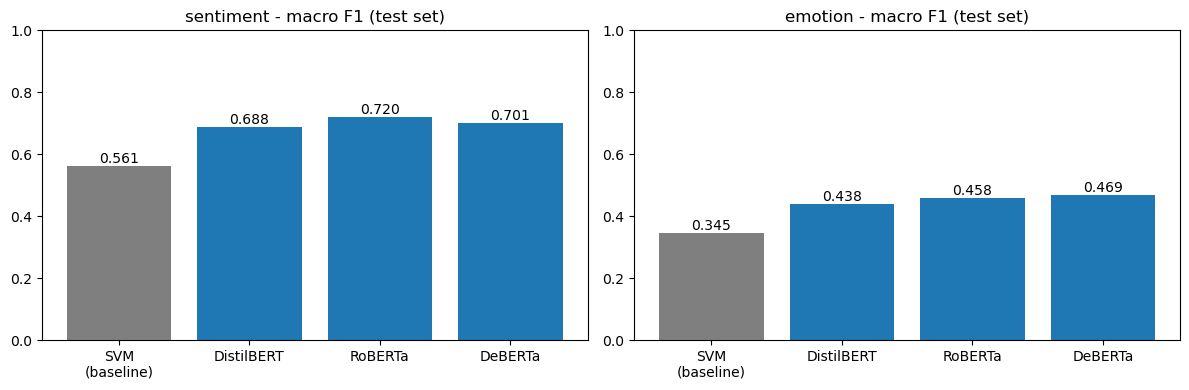

task,emotion,sentiment
model,,
svm_tfidf,0.3450,0.5612
distilbert,0.4383,0.6881
roberta,0.4577,0.7196
deberta,0.4691,0.7006


In [3]:
# ---- final comparison chart + summary table ----
order = ["svm_tfidf", "distilbert", "roberta", "deberta"]
labels = ["SVM\n(baseline)", "DistilBERT", "RoBERTa", "DeBERTa"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, task in zip(axes, ["sentiment", "emotion"]):
    d = results[results.task == task].set_index("model").reindex(order)
    bars = ax.bar(labels, d.f1_macro, color=["#7f7f7f", "#1f77b4", "#1f77b4", "#1f77b4"])
    ax.bar_label(bars, fmt="%.3f")
    ax.set_title(f"{task} - macro F1 (test set)"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(f"{RESULTS}/final_comparison.png", dpi=150); plt.show()

summary = results.pivot_table(index="model", columns="task", values="f1_macro").reindex(order)
summary.to_csv(f"{RESULTS}/summary_table.csv")
summary

In [4]:
# ---- computational efficiency: parameters, latency, throughput ----
sample = "delivery was late again and nobody answered my emails!!"
rows = []
for key in ["distilbert", "roberta", "deberta"]:
    path = f"{MODELS_DIR}/{key}_sentiment"
    tok = AutoTokenizer.from_pretrained(path)
    m = AutoModelForSequenceClassification.from_pretrained(path).to(device).eval()
    params = sum(p.numel() for p in m.parameters())
    with torch.no_grad():
        enc = tok(sample, return_tensors="pt").to(device)
        times = []
        for _ in range(30):
            t0 = time.time(); m(**enc); times.append(time.time() - t0)
        enc64 = tok([sample] * 64, return_tensors="pt", padding=True).to(device)
        t0 = time.time()
        for _ in range(5): m(**enc64)
        throughput = 320 / (time.time() - t0)
    rows.append({"model": key, "parameters_M": round(params / 1e6),
                 "size_MB": round(params * 4 / 1e6),
                 "latency_ms": round(np.median(times) * 1000, 1),
                 "throughput_texts_per_s": round(throughput)})
eff = pd.DataFrame(rows)
eff.to_csv(f"{RESULTS}/efficiency.csv", index=False)
eff

,model,parameters_M,size_MB,latency_ms,throughput_texts_per_s
0,distilbert,67,268,5.2,1747
1,roberta,125,499,9.1,1162
2,deberta,139,557,11.8,1179


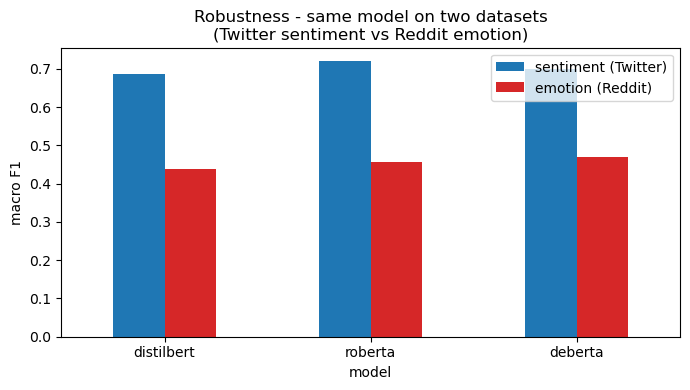

task,emotion,sentiment,relative_drop_%
model,,,
distilbert,0.4383,0.6881,36.3
roberta,0.4577,0.7196,36.4
deberta,0.4691,0.7006,33.0


In [5]:
# ---- robustness: how consistently does each architecture perform
# across the two datasets? (they differ in platform, text style and task difficulty)
piv = results[results.model != "svm_tfidf"].pivot_table(
    index="model", columns="task", values="f1_macro")
piv = piv.reindex(["distilbert", "roberta", "deberta"])

# relative drop from the easy task (sentiment) to the hard task (emotion):
# the smaller the drop, the more robust the architecture
piv["relative_drop_%"] = ((piv["sentiment"] - piv["emotion"]) / piv["sentiment"] * 100).round(1)

ax = piv[["sentiment", "emotion"]].plot(kind="bar", figsize=(7, 4),
                                        color=["#1f77b4", "#d62728"])
ax.set_title("Robustness - same model on two datasets\n(Twitter sentiment vs Reddit emotion)")
ax.set_ylabel("macro F1"); ax.legend(["sentiment (Twitter)", "emotion (Reddit)"])
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(f"{RESULTS}/robustness_across_datasets.png", dpi=150); plt.show()

piv


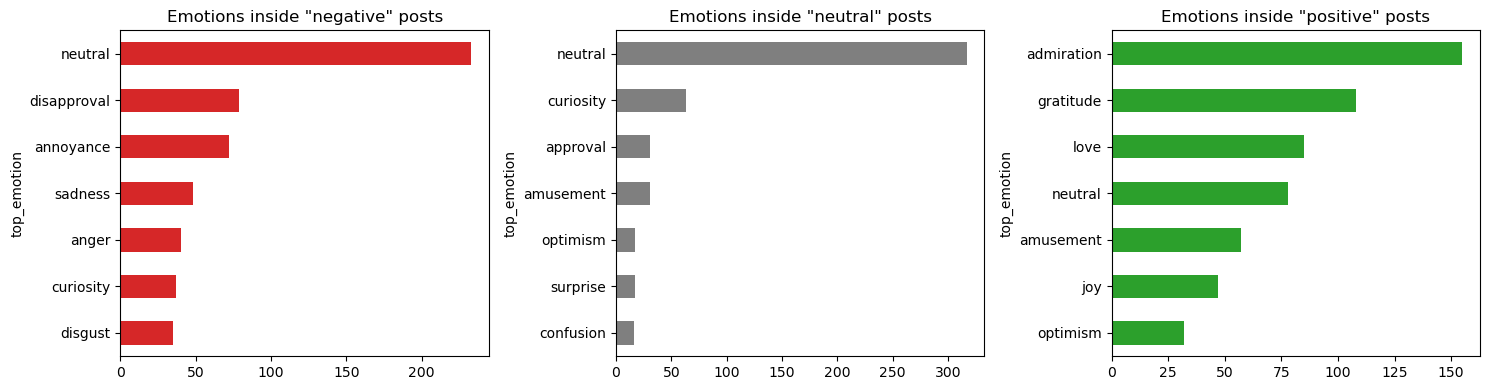

posts labelled negative: 772
distinct emotions hiding inside them: 20


top_emotion
neutral        0.301813
disapproval    0.102332
annoyance      0.093264
sadness        0.062176
anger          0.051813
curiosity      0.047927
Name: proportion, dtype: float64

In [6]:
# ---- RQ2: what does emotion add beyond sentiment? ----
# run BOTH models on the same posts and look inside each sentiment class
goemotions = load_from_disk(os.path.join(PROCESSED, "goemotions"))
emotion_names = goemotions["train"].features["labels"].feature.names
posts = goemotions["test"]["text"][:2000]

def predict(path, texts):
    tok = AutoTokenizer.from_pretrained(path)
    m = AutoModelForSequenceClassification.from_pretrained(path).to(device).eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), 64):
            enc = tok(texts[i:i+64], truncation=True, max_length=64,
                      padding=True, return_tensors="pt").to(device)
            out.extend(m(**enc).logits.argmax(dim=1).cpu().tolist())
    return out

sent = predict(f"{MODELS_DIR}/roberta_sentiment", posts)
emo = predict(f"{MODELS_DIR}/roberta_emotion", posts)

rq2 = pd.DataFrame({"text": posts,
                    "sentiment": [["negative", "neutral", "positive"][s] for s in sent],
                    "top_emotion": [emotion_names[e] for e in emo]})
rq2.to_csv(f"{RESULTS}/rq2_predictions.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, s, c in zip(axes, ["negative", "neutral", "positive"], ["#d62728", "#7f7f7f", "#2ca02c"]):
    rq2[rq2.sentiment == s]["top_emotion"].value_counts().head(7).sort_values().plot(
        kind="barh", ax=ax, color=c)
    ax.set_title(f'Emotions inside "{s}" posts')
plt.tight_layout(); plt.savefig(f"{RESULTS}/rq2_emotions_within_sentiment.png", dpi=150); plt.show()

neg = rq2[rq2.sentiment == "negative"]
print(f"posts labelled negative: {len(neg)}")
print("distinct emotions hiding inside them:", (neg.top_emotion.value_counts() > 5).sum())
neg.top_emotion.value_counts(normalize=True).head(6)

## Conclusion

Everything the report needs is now in `results/`:

- `experiments.csv` and `summary_table.csv` - the results tables
- `final_comparison.png` - headline figure (baseline vs the three transformers)
- `curve_*.png` / `cm_*.png` - learning curves and confusion matrices per run
- `efficiency.csv` - parameters / latency / throughput
- `cross_dataset_cm.png` - cross-platform robustness result
- `rq2_*` - the emotion-beyond-sentiment analysis